<a href="https://colab.research.google.com/github/Nandep-Desai/Python-2_25/blob/main/ch_7__2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
train_db=pd.read_csv('/content/drive/MyDrive/Colab Files/sign_mnist_train.csv')
valid_db=pd.read_csv('/content/drive/MyDrive/Colab Files/sign_mnist_valid.csv')


In [2]:
train_db.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [3]:
valid_db.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,9,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


In [4]:
y_train=train_db['label']
del train_db['label']
train_db.shape

(27455, 784)

In [5]:
y_valid=valid_db['label']
del valid_db['label']
valid_db.shape

(7172, 784)

In [6]:
x_train=train_db.values
x_valid=valid_db.values


In [7]:
print(x_train.shape)
print(x_valid.shape)

(27455, 784)
(7172, 784)


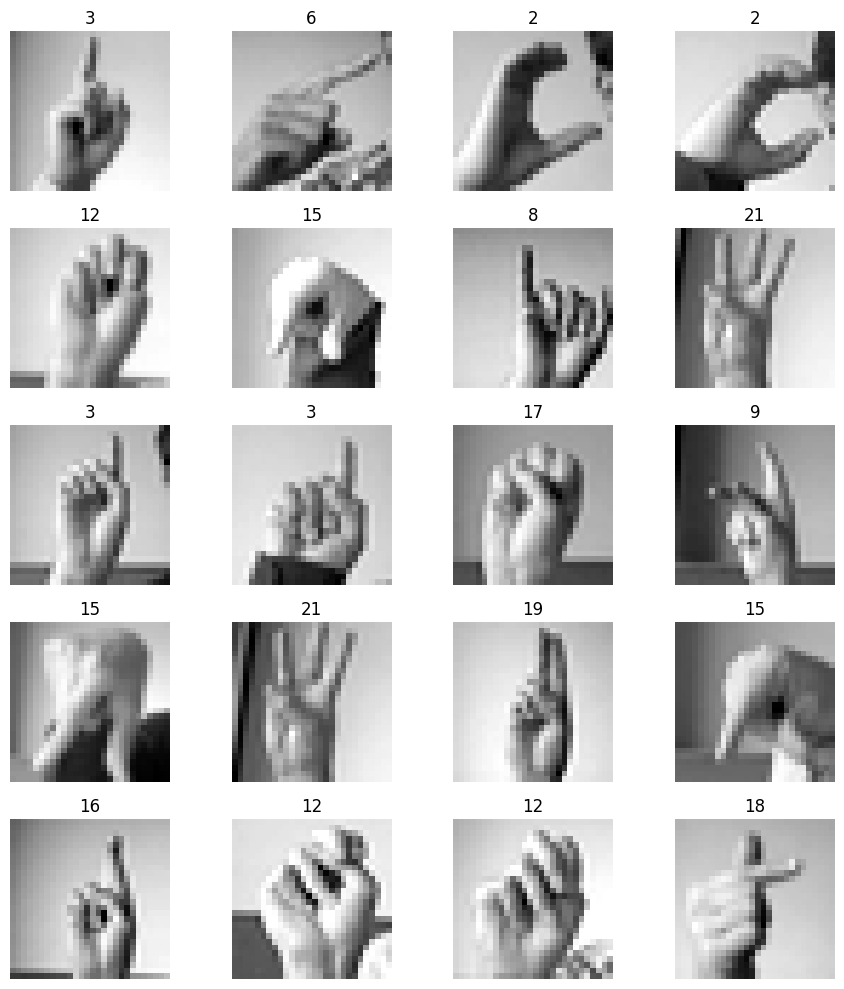

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(20):
  plt.subplot(5,4,i+1)
  row=x_train[i]
  label=y_train[i]
  plt.title(label)
  plt.axis('off')
  plt.imshow(row.reshape(28,28),cmap='gray')
  plt.tight_layout()
plt.show()

In [9]:
x_train.max()

np.int64(255)

In [10]:
x_valid.max()

np.int64(255)

In [11]:
x_train=x_train/255
x_valid=x_valid/255

In [12]:
from tensorflow.keras.utils import  to_categorical
y_train=to_categorical(y_train,24)
y_valid=to_categorical(y_valid,24)

In [13]:
y_train[0]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0.])

In [14]:
from tensorflow.keras.models import Sequential
model=Sequential()

In [15]:
from tensorflow.keras.layers import Dense
model.add(Dense(512,input_shape=(784,),activation='relu'))
model.add(Dense(512,activation='relu'))
model.add(Dense(24,activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │        12,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 676,888 (2.58 MB)

 Trainable params: 676,888 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Change the loss function identifier to the correct case and remove the underscore.
model.compile(loss='categorical_crossentropy',metrics=['accuracy'])

In [18]:
history=model.fit(x_train,y_train,epochs=3,verbose=1,validation_data=(x_valid,y_valid))

Epoch 1/3
858/858 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.2430 - loss: 2.4873 - val_accuracy: 0.3914 - val_loss: 1.9321
Epoch 2/3
858/858 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6275 - loss: 1.0970 - val_accuracy: 0.5311 - val_loss: 1.5827
Epoch 3/3
858/858 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7781 - loss: 0.6370 - val_accuracy: 0.7203 - val_loss: 0.8810


In [19]:
import pandas as pd
df=pd.DataFrame(history.history)
df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.384265,1.943577,0.391383,1.932125
1,0.674194,0.957612,0.531093,1.582722
2,0.801421,0.573524,0.720301,0.881029
